In [10]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

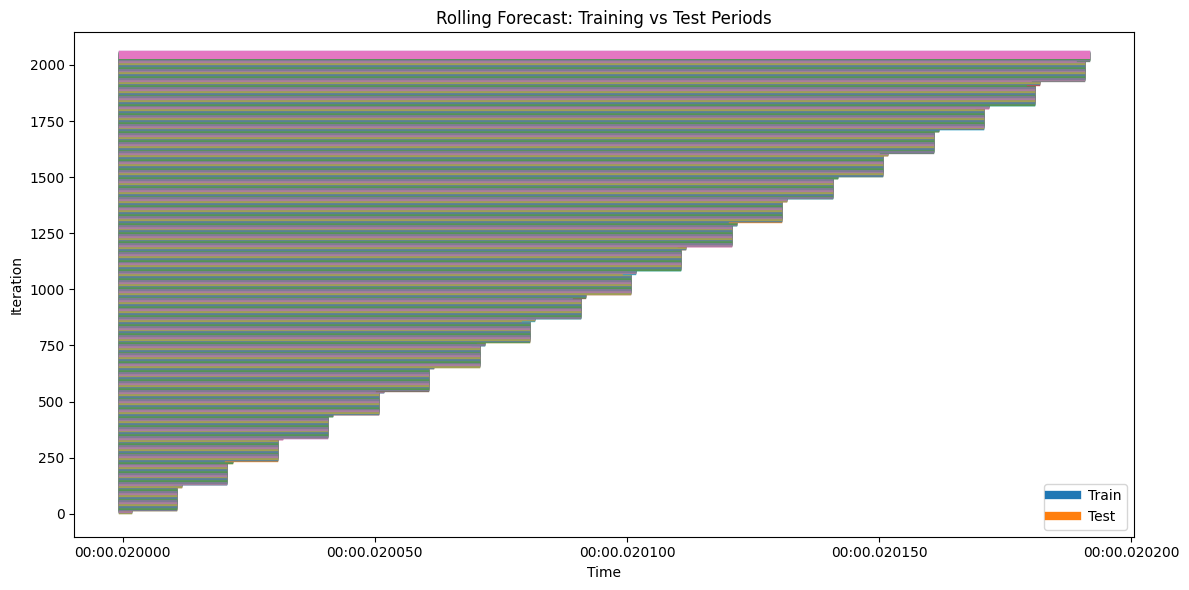

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/atp_matches_2000_2019_clean.csv")

# Muunna päivämäärä
df["tourney_date"] = pd.to_datetime(df["tourney_date"])

MIN_TRAIN = 2000
STEP = 25

timeline_data = []

for i in range(MIN_TRAIN, len(df), STEP):
    train_start = df.iloc[0]["tourney_date"]
    train_end = df.iloc[i-1]["tourney_date"]
    
    test_start = df.iloc[i]["tourney_date"]
    test_end = df.iloc[min(i+STEP-1, len(df)-1)]["tourney_date"]

    timeline_data.append({
        "train_start": train_start,
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end,
    })

timeline_df = pd.DataFrame(timeline_data)

plt.figure(figsize=(12, 6))

for i, row in timeline_df.iterrows():
    plt.plot(
        [row["train_start"], row["train_end"]],
        [i, i],
        linewidth=6,
        label="Train" if i == 0 else ""
    )
    
    plt.plot(
        [row["test_start"], row["test_end"]],
        [i, i],
        linewidth=6,
        label="Test" if i == 0 else ""
    )

plt.xlabel("Time")
plt.ylabel("Iteration")
plt.title("Rolling Forecast: Training vs Test Periods")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Generate three separate logistic function plots with consistent LaTeX-style axis labels

import numpy as np
import matplotlib.pyplot as plt

# Linear predictor range
x = np.linspace(-6, 6, 400)

betas = [0.5, 1.0, 2.0]

for beta in betas:
    p = 1 / (1 + np.exp(-beta * x))
    
    plt.figure()
    plt.plot(x, p)
    plt.xlabel(r"Linear predictor $\eta_i = X_i^\top \beta$")
    plt.ylabel(r"Predicted probability $p_i$")
    plt.title(f"Logistic Function ($\\beta$ = {beta})")
    plt.ylim(0, 1)
    plt.xlim(-6, 6)
    filename = f"logistic_beta_{beta}.png"
    plt.close()

print("Updated plots saved with consistent LaTeX-style axis labels.")



Updated plots saved with consistent LaTeX-style axis labels.


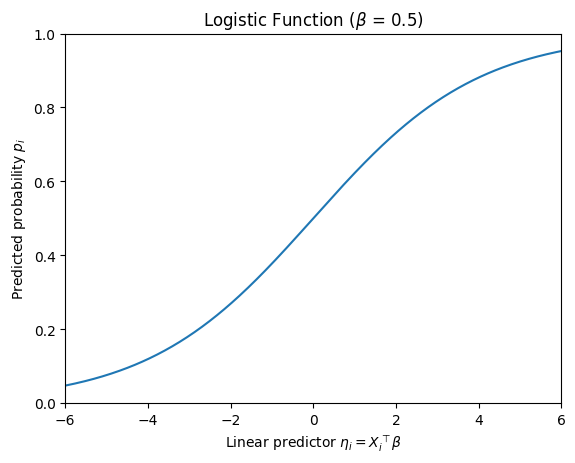

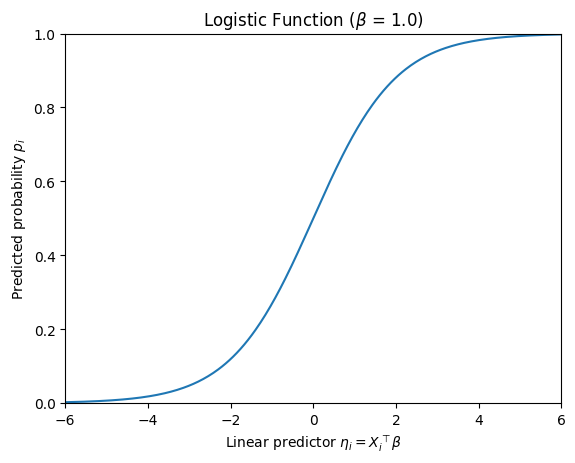

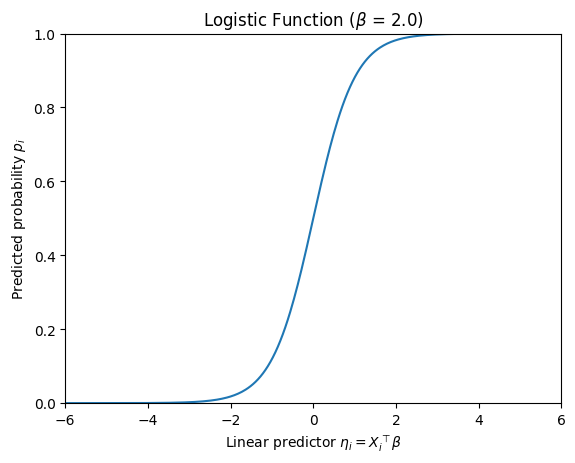

In [18]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 400)
betas = [0.5, 1.0, 2.0]

for beta in betas:
    p = 1 / (1 + np.exp(-beta * x))
    
    plt.figure()
    plt.plot(x, p)
    plt.xlabel(r"Linear predictor $\eta_i = X_i^\top \beta$")
    plt.ylabel(r"Predicted probability $p_i$")
    plt.title(f"Logistic Function ($\\beta$ = {beta})")
    plt.ylim(0, 1)
    plt.xlim(-6, 6)
    plt.show()

    filename = f"logistic_beta_{beta}_uniform_axes.png"
    save_path = "/Users/arttusokka/Documents/AThesis/Prediciting-ATP-matches-outcome/Kandinkuvaajat/"



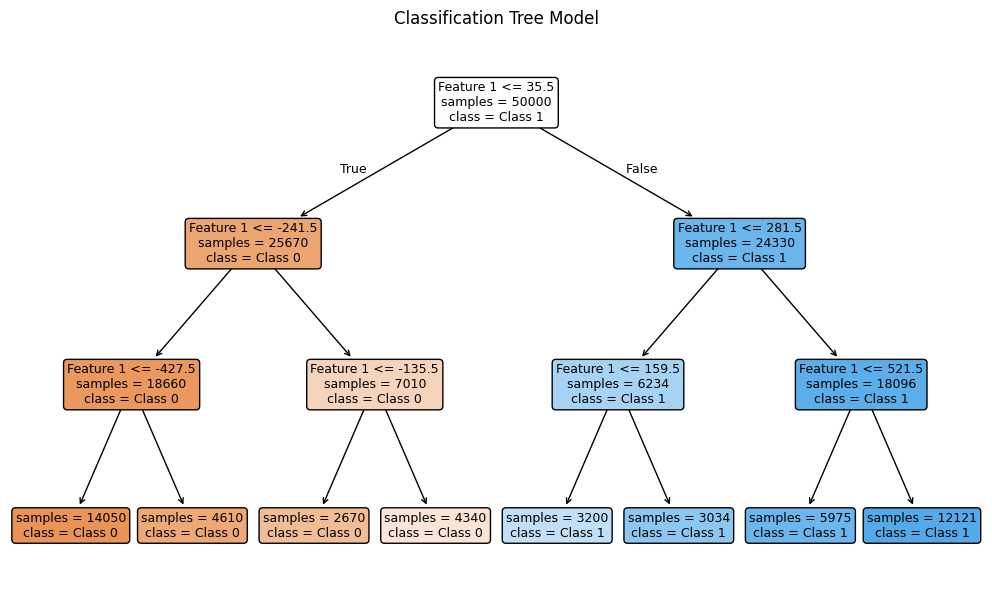

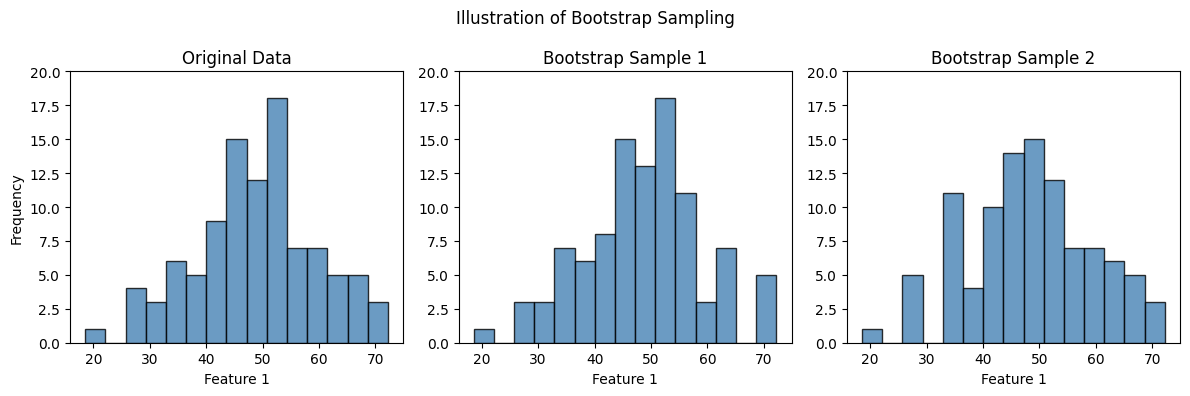

In [64]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 100
feature_1 = np.random.normal(loc=50, scale=12, size=n)

bootstrap_1 = np.random.choice(feature_1, size=n, replace=True)
bootstrap_2 = np.random.choice(feature_1, size=n, replace=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
color = "steelblue"

axes[0].hist(feature_1, bins=15, color=color, edgecolor="black", alpha=0.8)
axes[0].set_title("Original Data")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Frequency")

axes[1].hist(bootstrap_1, bins=15, color=color, edgecolor="black", alpha=0.8)
axes[1].set_title("Bootstrap Sample 1")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("")

axes[2].hist(bootstrap_2, bins=15, color=color, edgecolor="black", alpha=0.8)
axes[2].set_title("Bootstrap Sample 2")
axes[2].set_xlabel("Feature 1")
axes[2].set_ylabel("")

for ax in axes:
    ax.set_ylim(0, 20)
    
fig.suptitle("Illustration of Bootstrap Sampling", fontsize=12)

plt.tight_layout()
plt.savefig("bootstrap_generic.pdf", bbox_inches="tight")
plt.show()

NameError: name 'features' is not defined

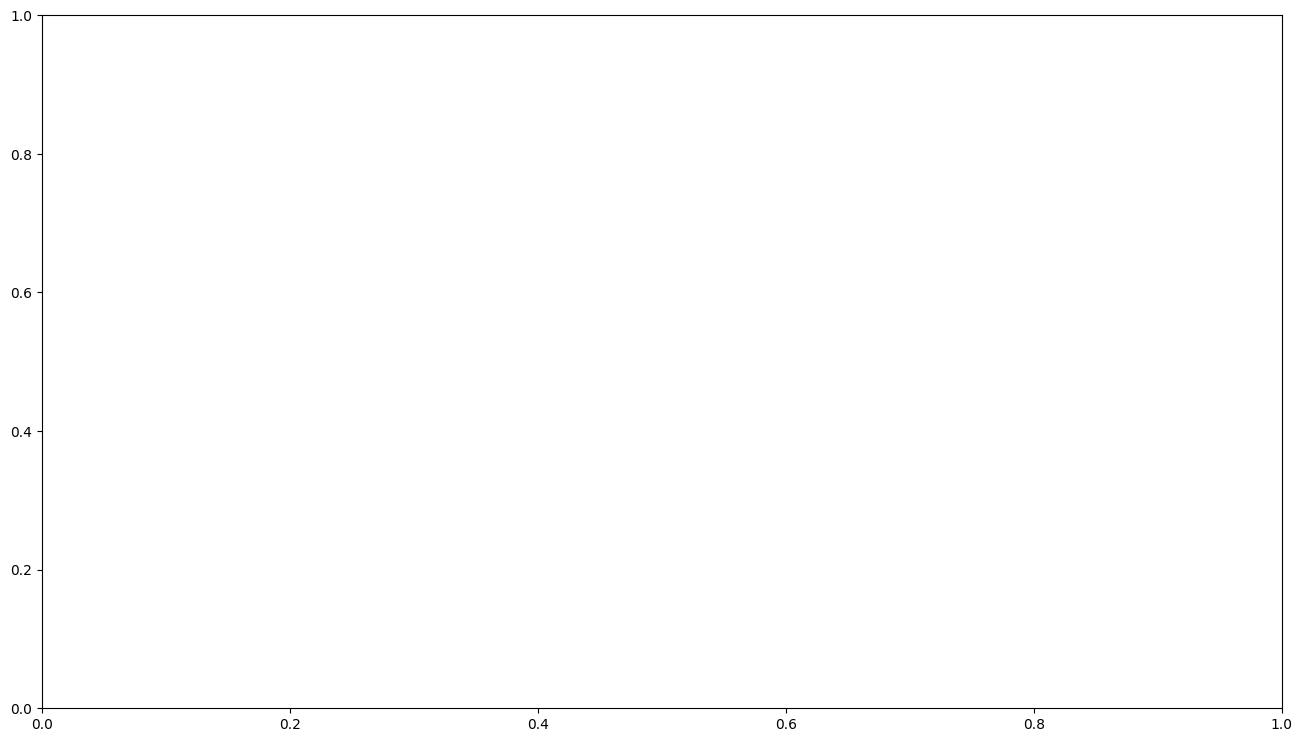

In [14]:
# Piirretään puu normaalisti
fig, ax = plt.subplots(figsize=(16, 9))

tree_plot = plot_tree(
    tree_vis,
    feature_names=features,
    class_names=["Loss", "Win"],
    filled=True,
    rounded=True,
    impurity=False,
    proportion=False,
    precision=2,
    fontsize=11,
)

# Poistetaan value-rivi jokaisesta laatikosta
for text in ax.texts:
    label = text.get_text()
    lines = label.split("\n")
    
    # Poistetaan rivit, jotka alkavat 'value'
    lines = [line for line in lines if not line.strip().startswith("value")]
    
    text.set_text("\n".join(lines))

plt.title("Classification Tree Model", fontsize=16)
plt.tight_layout()
plt.show()

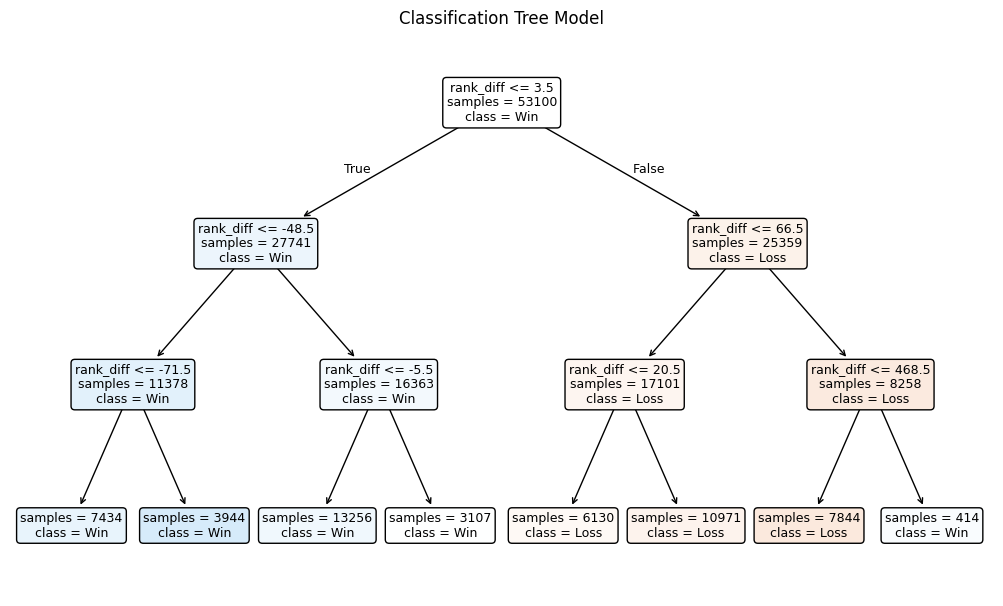

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))  # pienempi koko

#randomize feature with 50,000 observations


tree_plot = plot_tree(
    tree_vis,
    feature_names=feature,
    class_names=["True", "False"],
    filled=True,
    rounded=True,
    impurity=False,
    proportion=False,
    precision=2,
    fontsize=9   # pienempi fontti
)

# Poistetaan value-rivi
for text in ax.texts:
    label = text.get_text()
    lines = label.split("\n")
    lines = [line for line in lines if not line.strip().startswith("value")]
    text.set_text("\n".join(lines))

plt.title("Classification Tree Model", fontsize=12)

plt.tight_layout(pad=0.5)   # vähemmän marginaalia
plt.margins(0)              # poistaa ylimääräistä whitespacea
plt.savefig("classification_tree.pdf", bbox_inches="tight")

plt.show()

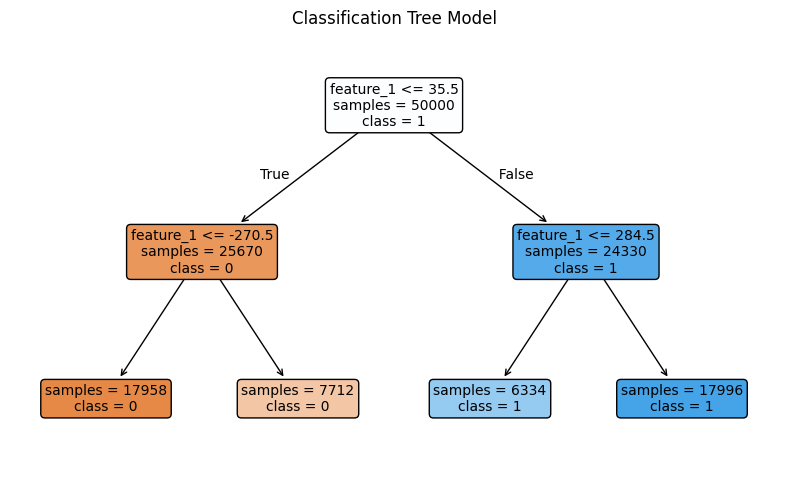

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

np.random.seed(42)
n = 50000

# Feature (kuten ennen)
feature_1 = np.random.randint(-1000, 1000, size=n)
X_vis = feature_1.reshape(-1, 1)

# 🔑 TÄRKEIN OSA: probabilistinen target (kuten oikeassa datassa!)
p = 1 / (1 + np.exp(-feature_1 / 200))   # sigmoid
y = (np.random.rand(n) < p).astype(int)

# Tree (älä rajoita liikaa)
tree_vis = DecisionTreeClassifier(
    max_depth=2,
    min_samples_leaf=500,
    random_state=1
)

tree_vis.fit(X_vis, y)

fig, ax = plt.subplots(figsize=(8, 5))  # pienempi canvas

plot_tree(
    tree_vis,
    feature_names=["feature_1"],
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    impurity=False,
    proportion=False,
    precision=2,
    fontsize=9,
    ax=ax
)

# Poistetaan value-rivi
for text in ax.texts:
    label = text.get_text()
    lines = label.split("\n")
    lines = [line for line in lines if not line.strip().startswith("value")]
    text.set_text("\n".join(lines))

plt.title("Classification Tree Model", fontsize=12)

# 🔑 TÄRKEÄT RIVIT
plt.tight_layout()
plt.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.02)

plt.savefig("classification_tree_generic.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

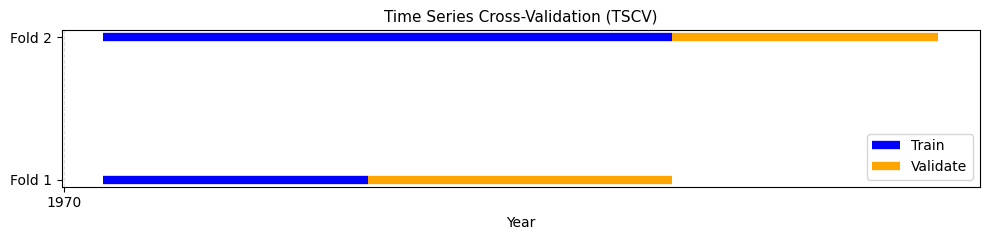

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.dates as mdates

# Load data
df = pd.read_csv("../data/atp_matches_2000_2019_clean.csv")
df["tourney_date"] = pd.to_datetime(df["tourney_date"])

tscv = TimeSeriesSplit(n_splits=2)

fig, ax = plt.subplots(figsize=(10, 2.5))  # pienempi korkeus

for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    
    y = fold * 0.4  # tuo foldit lähemmäs toisiaan
    
    # Train
    ax.hlines(
        y=y,
        xmin=df["tourney_date"].iloc[train_idx[0]],
        xmax=df["tourney_date"].iloc[train_idx[-1]],
        color="blue",
        linewidth=6,
        label="Train" if fold == 0 else ""
    )
    
    # Validation
    ax.hlines(
        y=y,
        xmin=df["tourney_date"].iloc[test_idx[0]],
        xmax=df["tourney_date"].iloc[test_idx[-1]],
        color="orange",
        linewidth=6,
        label="Validate" if fold == 0 else ""
    )

# Y-akseli tiiviiksi
ax.set_yticks([i * 0.4 for i in range(tscv.n_splits)])
ax.set_yticklabels([f"Fold {i+1}" for i in range(tscv.n_splits)])

# Fiksu päivämääräformatti
ax.xaxis.set_major_locator(mdates.YearLocator(2))  # joka 2. vuosi
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Labels
ax.set_title("Time Series Cross-Validation (TSCV)", fontsize=11)
ax.set_xlabel("Year")
ax.set_ylabel("")

ax.legend(loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

NameError: name 'v2' is not defined

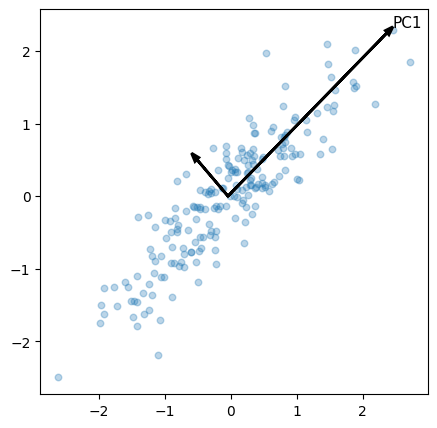

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Generate correlated data
np.random.seed(42)
x1 = np.random.normal(0, 1, 200)
x2 = 0.8 * x1 + np.random.normal(0, 0.4, 200)
X = np.column_stack((x1, x2))

# PCA
pca = PCA(n_components=2)
pca.fit(X)

mean = X.mean(axis=0)
components = pca.components_
variance = pca.explained_variance_

plt.figure(figsize=(5,5))

# Darker datapoints
plt.scatter(X[:,0], X[:,1], alpha=0.3, s=22)

vectors = []
for i in range(2):

    vector = components[i] * np.sqrt(variance[i]) * 2.75
    vectors.append(vector)

    plt.arrow(
        mean[0], mean[1],
        vector[0], vector[1],
        head_width=0.08,
        length_includes_head=True,
        linewidth=2,
        color="black"
    )

# Labels
plt.text(mean[0] + vectors[0][0], mean[1] + vectors[0][1], "PC1", fontsize=11)
plt.text(mean[0] + v2[0], mean[1] + v2[1] + 0.15, "PC2", fontsize=11)# Right-angle marker (square)
v1 = vectors[0] / np.linalg.norm(vectors[0])
v2 = vectors[1] / np.linalg.norm(vectors[1])

size = 0.25

p0 = mean
p1 = mean + v1 * size
p2 = p1 + v2 * size
p3 = mean + v2 * size

plt.plot(
    [p0[0], p1[0], p2[0], p3[0]],
    [p0[1], p1[1], p2[1], p3[1]],
    linewidth=1.8,
    color="black"
)

# Axes

plt.xlabel("$X_1$")
plt.ylabel("$X_2$", rotation=0, labelpad=15)
plt.axis("equal")
plt.grid(False)

plt.tight_layout(rect=[0,0,1,0.95])
plt.title("Principal Components of Correlated Features", fontsize=12)
plt.savefig("pca_visualization.pdf")
plt.show()

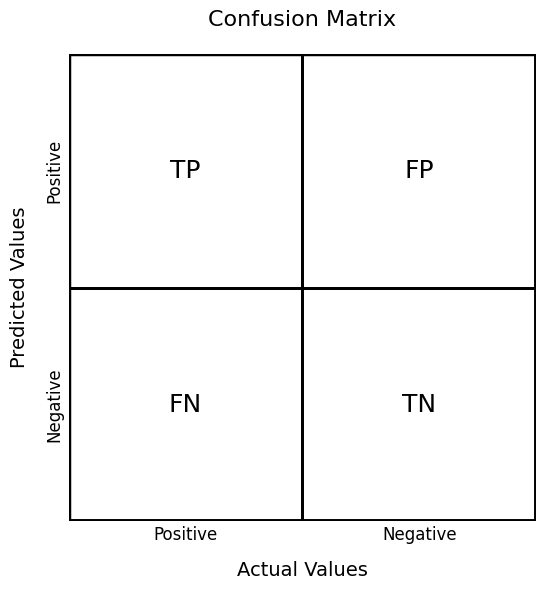

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(6, 6))

# Draw 2x2 grid
for i in range(2):
    for j in range(2):
        rect = Rectangle((j, 1 - i), 1, 1, fill=False, edgecolor="black", linewidth=2)
        ax.add_patch(rect)

# Strengthen outer borders
ax.plot([0, 2], [2, 2], color="black", linewidth=2.5)  # top
ax.plot([0, 2], [0, 0], color="black", linewidth=2.5)  # bottom
ax.plot([0, 0], [0, 2], color="black", linewidth=2.5)  # left
ax.plot([2, 2], [0, 2], color="black", linewidth=2.5)  # right

# Cell labels
ax.text(0.5, 1.5, "TP", ha="center", va="center", fontsize=18)
ax.text(1.5, 1.5, "FP", ha="center", va="center", fontsize=18)
ax.text(0.5, 0.5, "FN", ha="center", va="center", fontsize=18)
ax.text(1.5, 0.5, "TN", ha="center", va="center", fontsize=18)

# Axis labels
ax.set_xlabel("Actual Values", fontsize=14, labelpad=12)
ax.set_ylabel("Predicted Values", fontsize=14, labelpad=12)

# Tick labels
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["Positive", "Negative"], fontsize=12)

ax.set_yticks([1.5, 0.5])
ax.set_yticklabels(["Positive", "Negative"], fontsize=12, rotation=90, va="center")
outer = Rectangle((0, 0), 2, 2, fill=False, edgecolor="black", linewidth=2.8, zorder=10)
ax.add_patch(outer)
# Title
ax.set_title("Confusion Matrix", fontsize=16, pad=20)

# Style
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_aspect("equal")

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0)

plt.tight_layout()
plt.show()